In [1]:
import numpy as np 
import torch
import xarray as xr

import sys
sys.path.append('../')
import dpa_ensemble as de
import utils as ut
import evaluation
from engression.loss_func import energy_loss, energy_loss_two_sample#
import matplotlib.pyplot as plt
import json
from pathlib import Path
import os

In [2]:
import torch

def pca_reconstruct_rmse(X, n_components):
    """
    X: (n_samples, n_features) torch tensor
    n_components: number of principal components to keep
    """

    # 1. Center data
    X_mean = X.mean(dim=0)
    print("input (X) shape:", X.shape)
    print("X_mean shape:", X_mean.shape)
    X_centered = X - X_mean

    # 2. PCA via SVD
    U, S, Vt = torch.linalg.svd(X_centered, full_matrices=False)
    print("Vt shape:", Vt.shape)

    # 3. Keep top PCs
    Vt_k = Vt[:n_components]                # (k, n_features)

    # 4. Projection
    X_proj = X_centered @ Vt_k.T           # (n_samples, k)
    print("projection shape:", X_proj.shape)
    
    # 5. Reconstruction
    X_rec = X_proj @ Vt_k + X_mean         # (n_samples, n_features)
    print("Reconstruction shape:", X_rec.shape)
    
    # 6. RMSE per sample
    mse = torch.mean((X - X_rec)**2, dim=1)  # (n_samples,)
    rmse = torch.sqrt(mse)
    print("Reconstruction shape:", X_rec.shape)
    return X_rec, rmse


def pca_reconstruct_rmse_highprec(X, n_components=None, use_cpu=False):
    """
    High-precision PCA reconstruction.
    - Computes in float64 to minimize rounding error.
    - Optionally runs on CPU (can be more stable / avoids GPU tf32).
    """
    device = X.device
    X64 = X.detach()

    if use_cpu:
        X64 = X64.to("cpu")

    X64 = X64.to(torch.float64)

    # 1) Center (keepdim avoids extra broadcast quirks)
    X_mean = X64.mean(dim=0, keepdim=True)
    Xc = X64 - X_mean

    # 2) SVD
    U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)

    # "all PCs" means r = Vt.shape[0] = min(n_samples, n_features)
    r = Vt.shape[0]
    if n_components is None:
        n_components = r
    else:
        n_components = min(int(n_components), r)

    # 3) Reconstruct using U, S, Vt directly (fewer ops than proj+recon)
    U_k = U[:, :n_components]
    S_k = S[:n_components]
    Vt_k = Vt[:n_components, :]

    X_rec64 = (U_k * S_k) @ Vt_k + X_mean  # still float64

    # 4) RMSE in float64
    rmse64 = torch.sqrt(torch.mean((X64 - X_rec64) ** 2, dim=1))

    # Return to original device/dtype if desired
    X_rec = X_rec64.to(device=device, dtype=X.dtype)
    rmse = rmse64.to(device=device, dtype=X.dtype)

    return X_rec, rmse


def pca_variance_explained(X):
    # X: (n_samples, n_features)
    Xc = X - X.mean(dim=0, keepdim=True)

    # SVD: Xc = U diag(S) Vt
    U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)

    # eigenvalues of covariance = S^2 / (n_samples - 1)
    n = Xc.shape[0]
    eigvals = (S**2) / (n - 1)

    # explained variance ratio per PC + cumulative
    evr = eigvals / eigvals.sum()
    cev = torch.cumsum(evr, dim=0)
    return evr, cev


In [ ]:
#ds = xr.open_mfdataset(
#    "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/*cam*.nc",
#    combine="by_coords",
#    parallel=True
#)
#ds


In [3]:
path_raw = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/"
#file = "b.e21.f09_g17.LE2-1001.001.cam.h1.TREFHT.1850-2100.nc"
#file = "b.e21.f09_g17.LE2-1011.001.cam.h1.TREFHT.1850-2100.nc"
#file = "b.e21.f09_g17.LE2-1021.002.cam.h1.TREFHT.1850-2100.nc"
#file = "b.e21.f09_g17.LE2-1031.002.cam.h1.TREFHT.1850-2100.nc"
#file = "b.e21.f09_g17.LE2-1041.003.cam.h1.TREFHT.1850-2100.nc"
file = "b.e21.f09_g17.LE2-1051.003.cam.h1.TREFHT.1850-2100.nc"
path = os.path.join(path_raw, file)
ds_raw = xr.open_dataset(path)
ds = ds_raw.assign_coords(lon=(((ds_raw.lon + 180) % 360) - 180)).sortby("lon")
ds

<xarray.Dataset> Size: 20GB
Dimensions:    (time: 91615, bnds: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 733kB 1850-01-01 00:00:00 ... 2100-12-31 00:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
Dimensions without coordinates: bnds
Data variables: (12/14)
    time_bnds  (time, bnds) object 1MB ...
    gw         (lat) float64 2kB ...
    date       (time) int32 366kB ...
    datesec    (time) int32 366kB ...
    ndcur      (time) int32 366kB ...
    nscur      (time) int32 366kB ...
    ...         ...
    n2ovmr     (time) float64 733kB ...
    f11vmr     (time) float64 733kB ...
    f12vmr     (time) float64 733kB ...
    sol_tsi    (time) float64 733kB ...
    nsteph     (time) int32 366kB ...
    TREFHT     (time, lat, lon) float32 20GB ...
Attributes:
    CDI:               Climate Data Interface version 2.2.4 (https://mpimet.m...
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BHISTsmbb.f09_g17.LE2-1051.003
    logname:           sunseon
    host:              mom2
    initial_file:      b.e21.B1850.f09_g17.CMIP6-piControl.001.cam.i.1051-01-...
    topography_file:   /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/fv_0.9x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1
    history:           Thu Sep 25 01:48:05 2025: cdo mergetime /climca/people...
    CDO:               Climate Data Operators version 2.2.2 (https://mpimet.m...

In [4]:
t_eur = ds.TREFHT.sel(lat = slice(34,64), lon=slice(-11.5,28))#.isel(time=0)
#t_eur.plot()
t_eur

<xarray.DataArray 'TREFHT' (time: 91615, lat: 32, lon: 32)> Size: 375MB
[93813760 values with dtype=float32]
Coordinates:
  * time     (time) object 733kB 1850-01-01 00:00:00 ... 2100-12-31 00:00:00
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
Attributes:
    long_name:     Reference height temperature
    units:         K
    cell_methods:  time: mean

In [5]:
####################
### Load my data ###
####################

settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v4_dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)

ds = xr.open_dataset(settings['dataset_trefht'])

print("Dataset:", settings['dataset_trefht'])

# set train/test split
ds_train = ds.isel(time=slice(0, 4769 * 10)) #4769 * 80
#ds_test = ds.isel(time=slice(4769 * 10, 476900)) #4769 * 80

print(ds_train.TREFHT.shape)
#print(ds_test.TREFHT.shape)


# transform to torch tensors
x_tr = ut.data_to_torch(ds_train, "TREFHT")
x_tr_raw = ut.data_to_torch(t_eur, "TREFHT")
#x_te = ut.data_to_torch(ds_test, "TREFHT")

print("x_tr shape:", x_tr.shape)
#print(x_te.shape)

# remove NaNs from data
x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)
print("x train reduced shape:", x_tr_reduced.shape)

Dataset: /work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/v4_starting08122025/europe_10percent_masked_stacked_TREFHT_JJA_v3.nc
(32, 32, 47690)
torch.Size([47690, 1024])
torch.Size([91615, 1024])
x_tr shape: torch.Size([47690, 1024])
x train reduced shape: torch.Size([47690, 648])


In [5]:
#print(x_tr_raw.shape)


# Select JJA months
t_eur_jja = t_eur.where(t_eur['time'].dt.month.isin([6, 7, 8]), drop=True)
t_eur_jja

<xarray.DataArray 'TREFHT' (time: 23092, lat: 32, lon: 32)> Size: 95MB
array([[[292.84146, 293.12476, 294.35568, ..., 292.62323, 292.88904,
         293.10672],
        [292.63818, 292.90707, 294.135  , ..., 293.15677, 293.3161 ,
         293.22397],
        [292.44202, 292.64014, 293.76785, ..., 292.73398, 292.80893,
         292.44205],
        ...,
        [280.60336, 280.65216, 280.71582, ..., 287.1783 , 287.88617,
         288.49786],
        [279.80927, 279.92557, 279.94797, ..., 287.57288, 288.48642,
         289.0183 ],
        [278.8477 , 279.13107, 279.28558, ..., 288.12134, 288.4549 ,
         287.74734]],

       [[292.30768, 292.46213, 292.66583, ..., 292.66467, 292.73468,
         292.9168 ],
        [292.02765, 292.2319 , 292.68106, ..., 293.0834 , 292.87976,
         292.9566 ],
        [291.79095, 292.01587, 292.64014, ..., 292.7223 , 292.6769 ,
         292.2549 ],
...
        [285.7337 , 285.54922, 285.41965, ..., 290.08957, 289.8689 ,
         289.46213],
        [285.00827, 284.81293, 284.81635, ..., 289.09174, 288.9851 ,
         288.56653],
        [284.33365, 284.24435, 284.32562, ..., 287.76688, 287.56595,
         287.7531 ]],

       [[299.03833, 300.23044, 302.4984 , ..., 302.2583 , 301.93936,
         299.6214 ],
        [297.96475, 299.24277, 301.7847 , ..., 302.95938, 301.95486,
         301.56863],
        [296.57562, 297.93896, 300.4919 , ..., 301.47867, 301.92566,
         302.6547 ],
        ...,
        [285.30685, 285.31064, 285.24182, ..., 288.32336, 288.74518,
         289.55072],
        [284.7454 , 284.5493 , 284.15356, ..., 288.65002, 289.07175,
         289.37558],
        [283.84744, 283.64297, 283.26944, ..., 288.58826, 288.69507,
         289.2125 ]]], shape=(23092, 32, 32), dtype=float32)
Coordinates:
  * time     (time) object 185kB 1850-06-01 00:00:00 ... 2100-08-31 00:00:00
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
Attributes:
    long_name:     Reference height temperature
    units:         K
    cell_methods:  time: mean

In [6]:
# turn back into dataset
t_eur_ds = t_eur_jja.to_dataset(name="TREFHT")

t_eur_jja_torch = ut.data_to_torch(t_eur_ds, "TREFHT")

torch.Size([23092, 1024])


In [8]:
t_eur_jja

<xarray.DataArray 'TREFHT' (time: 23092, lat: 32, lon: 32)> Size: 95MB
array([[[292.84146, 293.12476, 294.35568, ..., 292.62323, 292.88904,
         293.10672],
        [292.63818, 292.90707, 294.135  , ..., 293.15677, 293.3161 ,
         293.22397],
        [292.44202, 292.64014, 293.76785, ..., 292.73398, 292.80893,
         292.44205],
        ...,
        [280.60336, 280.65216, 280.71582, ..., 287.1783 , 287.88617,
         288.49786],
        [279.80927, 279.92557, 279.94797, ..., 287.57288, 288.48642,
         289.0183 ],
        [278.8477 , 279.13107, 279.28558, ..., 288.12134, 288.4549 ,
         287.74734]],

       [[292.30768, 292.46213, 292.66583, ..., 292.66467, 292.73468,
         292.9168 ],
        [292.02765, 292.2319 , 292.68106, ..., 293.0834 , 292.87976,
         292.9566 ],
        [291.79095, 292.01587, 292.64014, ..., 292.7223 , 292.6769 ,
         292.2549 ],
...
        [285.7337 , 285.54922, 285.41965, ..., 290.08957, 289.8689 ,
         289.46213],
        [285.00827, 284.81293, 284.81635, ..., 289.09174, 288.9851 ,
         288.56653],
        [284.33365, 284.24435, 284.32562, ..., 287.76688, 287.56595,
         287.7531 ]],

       [[299.03833, 300.23044, 302.4984 , ..., 302.2583 , 301.93936,
         299.6214 ],
        [297.96475, 299.24277, 301.7847 , ..., 302.95938, 301.95486,
         301.56863],
        [296.57562, 297.93896, 300.4919 , ..., 301.47867, 301.92566,
         302.6547 ],
        ...,
        [285.30685, 285.31064, 285.24182, ..., 288.32336, 288.74518,
         289.55072],
        [284.7454 , 284.5493 , 284.15356, ..., 288.65002, 289.07175,
         289.37558],
        [283.84744, 283.64297, 283.26944, ..., 288.58826, 288.69507,
         289.2125 ]]], shape=(23092, 32, 32), dtype=float32)
Coordinates:
  * time     (time) object 185kB 1850-06-01 00:00:00 ... 2100-08-31 00:00:00
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
Attributes:
    long_name:     Reference height temperature
    units:         K
    cell_methods:  time: mean

X_rec.shape torch.Size([23092, 1024])
torch.Size([23092])


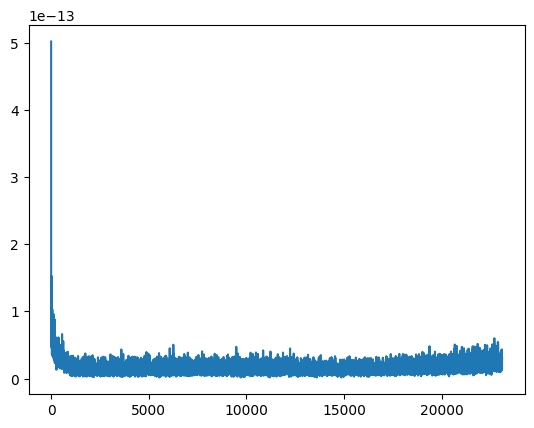

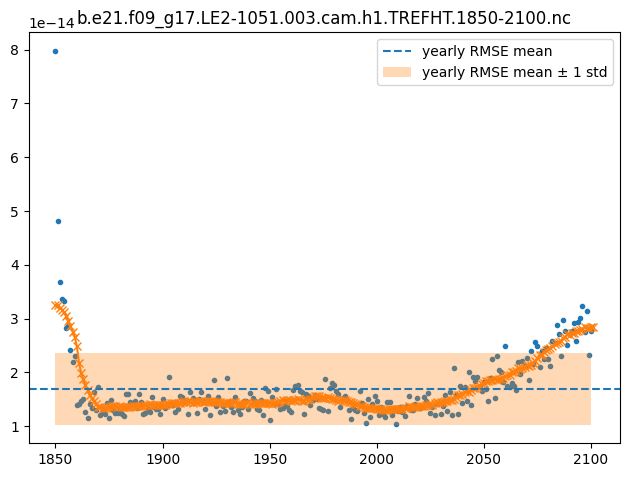

In [7]:
# compute PCA, RMSE
# all time
X = t_eur_jja_torch #x_tr_raw #x_tr_reduced
no_pcs = 1024#648
X_rec, rmse = pca_reconstruct_rmse_highprec(X, no_pcs)


print("X_rec.shape", X_rec.shape)
print(rmse.shape)
n=0
plt.plot(rmse)
plt.show()

# create dataarray
rmse_da = xr.DataArray(
    rmse.detach().cpu().numpy(),
    dims=("time",),
    coords={"time": t_eur_jja.time},
    name="RMSE",
)

# compute RMSE yearly mean
rmse_yearly = rmse_da.resample(time="YS").mean()
plt.scatter(range(1850,2101), rmse_yearly.values, marker=".")

# moving average
w = 20
kernel = np.ones(w) / w
pad = w // 2
x_pad = np.pad(rmse_yearly.values, (pad, pad), mode="reflect")
rmse_smooth = np.convolve(x_pad, kernel, mode="valid")
#rmse_smooth = np.convolve(rmse_yearly.values, np.ones(10)/10, mode="same")  # window=19


# PLOT
plt.plot(range(1850,2102), rmse_smooth, marker="x", color="tab:orange")
Y=rmse_yearly.values

# plot mean and standard deviation
mu = Y.mean(axis=0)
sd = Y.std(axis=0, ddof=1)

plt.axhline(mu, linestyle="--", label="yearly RMSE mean")
plt.fill_between(range(1850,2101), mu - sd, mu + sd, alpha=0.3, label="yearly RMSE mean ± 1 std")
plt.legend()
plt.tight_layout()
plt.title(file)
#plt.savefig(f"pca_results/{file}.pdf")
plt.show()

X_rec.shape torch.Size([23092, 1024])
torch.Size([23092])


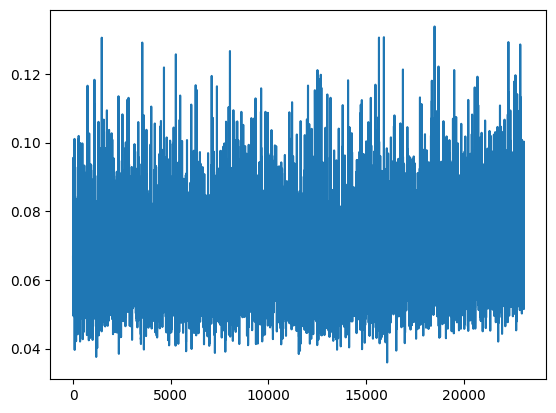

RuntimeError: shape '[10, 4769]' is invalid for input of size 23092

In [17]:




### RMSE ###

# reshape RMSE to calculate mean across 10 training members
rmse_res = rmse.reshape((10,4769))
plt.plot(rmse_res[0,n*4769+1000:(n+1)*4769])
plt.show()
print("RMSE_res shape",rmse_res.shape)
rmse_mean = rmse_res.mean(dim=0)
ts = rmse_mean  # shape (4769,) torch tensor (or any 1D tensor)
print("RMSE_mean shape",rmse_mean.shape)

# calculate yearly mean values
block = 19
n_blocks = ts.numel() // block 
ts19 = ts[:n_blocks * block].reshape(n_blocks, block).mean(dim=1)

# plot
plt.plot(range(1850,2101), ts19)
plt.xlabel("Year")
plt.ylabel("Spatial RMSE")
plt.title(f"TREFHT RMSE from PC (={no_pcs}PCs, mean of 10 \ntraining members) reconstruction Europe 32x32")
plt.tight_layout()
plt.savefig(f"figures/RMSE_from_{no_pcs}_PCAs.pdf")
plt.show()

plt.plot(rmse_mean)
#plt.title()

In [ ]:
evr, cev = pca_variance_explained(X)

# Variance explained per PC
plt.figure()
plt.plot(evr.detach().cpu().numpy())
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Variance explained per PC")
plt.tight_layout()
plt.xlim(0,10)
plt.show()

# Optional: cumulative variance explained
plt.figure()
plt.plot(cev.detach().cpu().numpy())
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Cumulative variance explained")
plt.ylim(0, 1.01)
plt.tight_layout()
plt.show()

torch.Size([10, 1900, 648])


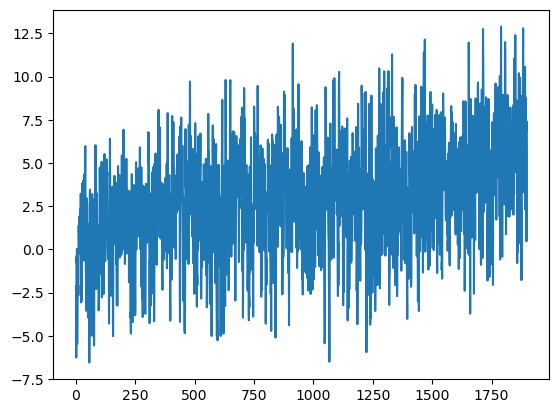

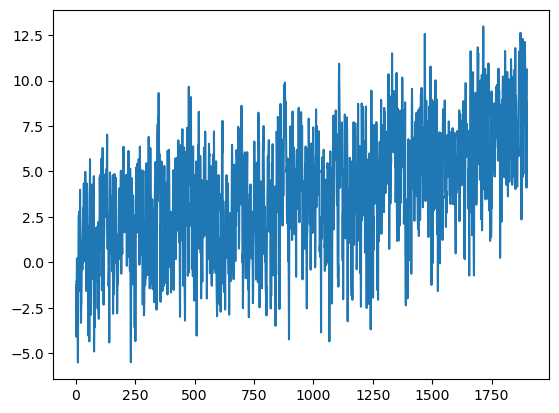

In [55]:
# only 2000 - 2100
# is this correct?
X = x_tr_reduced.reshape((10, 4769,648))[:,-1900:4769,:]
print(X.shape)
plt.plot(X[0,:,1])
plt.show()
X_re = X.reshape((19000,648))
plt.plot(X_re[:1900,100])

tensor([0.2298, 0.2324, 0.2082,  ..., 0.2771, 0.2431, 0.2132])
torch.Size([10, 1900])


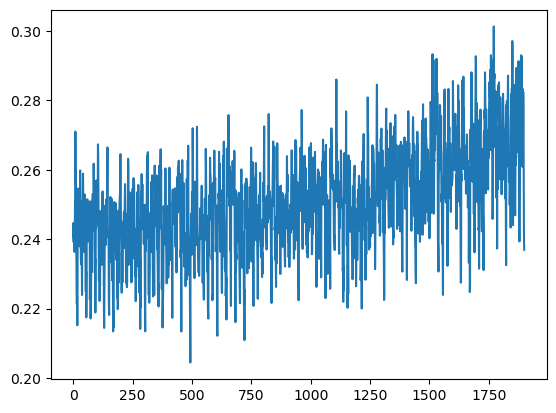

In [57]:
X_rec, rmse = pca_reconstruct_rmse(X_re, 100)

print(rmse)   # RMSE for each sample
rmse.shape

rmse_res = rmse.reshape((10,1900))
print(rmse_res.shape)
rmse_mean = rmse_res.mean(dim=0)
rmse_mean.shape
plt.plot(rmse_mean)